# Homework 1


## Import iris dataset


In [1]:
from sklearn.datasets import load_iris

iris_data = load_iris()

## Make scatterplots

Code based off of seaborn docs tutorial


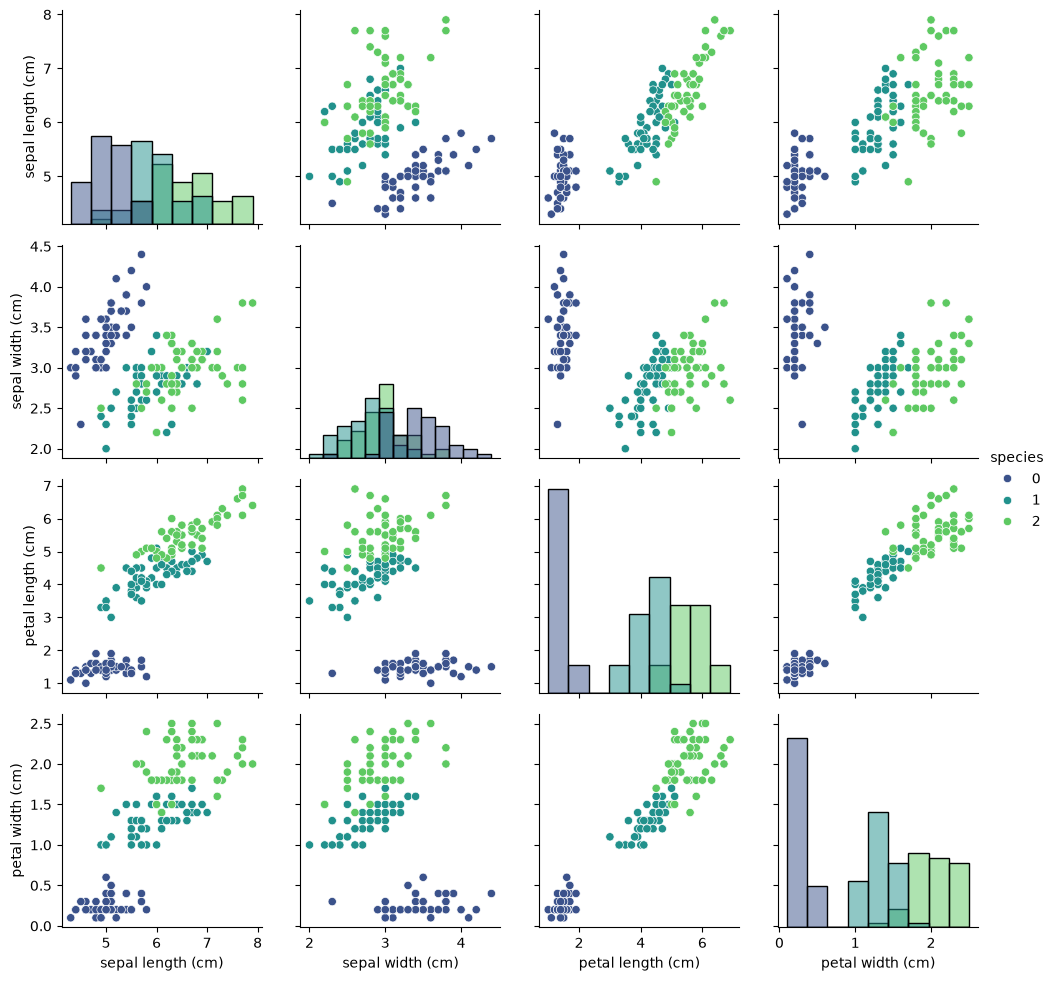

In [2]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(
    data=iris_data.data, columns=iris_data.feature_names
)  # make dataframe from data
df["species"] = iris_data.target  # add targets as column

g = sns.PairGrid(df, hue="species", palette=sns.color_palette("viridis", n_colors=3))
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

## Split Data

Making use of built in train_test_split function


In [3]:
from sklearn.model_selection import train_test_split

X, y = iris_data.data, iris_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6220)

## Train model


In [4]:
import time

from sklearn.pipeline import Pipeline


def train_test_benchmark(pipe: Pipeline, name: str):
    train_start = time.time()
    pipe = pipe.fit(X_train, y_train)
    train_end = time.time()
    train_secs = train_end - train_start

    test_start = time.time()
    accuracy = pipe.score(X_test, y_test)
    test_end = time.time()
    test_secs = test_end - test_start

    print(f"{name}:")
    print(f"Train Time: {train_secs:.5f} seconds")
    print(f"Test Time: {test_secs:.5f} seconds")
    print(f"Accuracy: {accuracy:.5f}")
    print()

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

lr_pipe = Pipeline([("lr", LogisticRegression())])
nns_pipe = Pipeline([("nns", KNeighborsRegressor(n_neighbors=5))])
dt_pipe = Pipeline([("dt", DecisionTreeRegressor())])

train_test_benchmark(lr_pipe, "Logistic Regression")
train_test_benchmark(nns_pipe, "Nearest Neighbor")
train_test_benchmark(dt_pipe, "Decision Tree")

Logistic Regression:
Train Time: 0.02421 seconds
Test Time: 0.00098 seconds
Accuracy: 0.93333

Nearest Neighbor:
Train Time: 0.00081 seconds
Test Time: 0.00129 seconds
Accuracy: 0.87557

Decision Tree:
Train Time: 0.00069 seconds
Test Time: 0.00061 seconds
Accuracy: 0.89455

